In [4]:
!pip install -q stanza nltk

import json
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
from nltk.util import ngrams
from collections import Counter
import stanza


nltk.download('punkt')
nltk.download('punkt_tab') # Download the missing resource
stanza.download("kk")  # Kazakh lemmatization model

stemmer = SnowballStemmer("russian")  # works decently for Kazakh Cyrillic
nlp = stanza.Pipeline("kk")           # for true Kazakh lemmatization

with open("abai-sozderi.json", "r", encoding="utf-8") as f:
    data = json.load(f)

texts = [item["text"] for item in data]

# STEP 1–4: CLEANING + STEMMING
processed_texts = []
for text in texts:
    text_no_punct = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text_lower = text_no_punct.lower()                                         # lowercase
    tokens = word_tokenize(text_lower)                                         # tokenize
    stemmed = [stemmer.stem(t) for t in tokens if t.isalpha()]                 # stem and remove non-alpha
    processed_texts.append(stemmed)

print(" Stemming done. Example tokens:\n", processed_texts[0][:20]);

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: kk (Kazakh) ...
INFO:stanza:File exists: /root/stanza_resources/kk/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: kk (Kazakh):
| Processor | Package      |
----------------------------
| tokenize  | ktb          |
| mwt       | ktb          |
| pos       | ktb_charlm   |
| lemma     | ktb_nocharlm |
| depparse  | ktb_charlm   |
| ner       | kazNERD      |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!


 Stemming done. Example tokens:
 ['бұл', 'жасқ', 'келгенш', 'жақс', 'өткіздік', 'пе', 'жама', 'өткіздік', 'пе', 'әйтеуір', 'біртала', 'өмірімізді', 'өткіздік', 'алыстық', 'жұлыстық', 'айтыстық', 'тартыстық', 'әурешілікті', 'көрекөр', 'келдік']


In [5]:
from nltk.corpus import stopwords
nltk.download('stopwords')

# Combine Kazakh stopwords + your own Kazakh words
stop_words = set(stopwords.words('russian')) | {"мен", "да", "де", "не", "ғана", "пе", "деп", "ол", "бір", "еді", "ек", "бар", "жоқ", "болс"}

# The original code had `lemmatized_texts` here, which was not defined.
# Assuming the intention was to filter the `processed_texts` from the stemming step.
# If lemmatization is needed, a step for that should be added before this.
filtered_processed_texts = [
    [word for word in stemmed_words if word not in stop_words]
    for stemmed_words in processed_texts
]

print(" Processed words after stopword removal:", filtered_processed_texts[0][:20])

 Processed words after stopword removal: ['бұл', 'жасқ', 'келгенш', 'жақс', 'өткіздік', 'жама', 'өткіздік', 'әйтеуір', 'біртала', 'өмірімізді', 'өткіздік', 'алыстық', 'жұлыстық', 'айтыстық', 'тартыстық', 'әурешілікті', 'көрекөр', 'келдік', 'енді', 'жер']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
# STEP 6: N-GRAM GENERATION
# Using filtered_processed_texts for n-gram generation
n_grams_data = []
for i, words in enumerate(filtered_processed_texts, start=1):
    bigrams = [" ".join(bg) for bg in ngrams(words, 2)]
    trigrams = [" ".join(tg) for tg in ngrams(words, 3)]
    n_grams_data.append({
        "number": i,
        "words": words, # Changed from 'lemmas' to 'words'
        "bigrams": bigrams,
        "trigrams": trigrams
    })

print("\n N-grams generated. Sample bigrams:\n", n_grams_data[0]["bigrams"][:10])




 N-grams generated. Sample bigrams:
 ['бұл жасқ', 'жасқ келгенш', 'келгенш жақс', 'жақс өткіздік', 'өткіздік жама', 'жама өткіздік', 'өткіздік әйтеуір', 'әйтеуір біртала', 'біртала өмірімізді', 'өмірімізді өткіздік']


In [7]:

# STEP 7: FREQUENCY ANALYSIS
# Using filtered_processed_texts for frequency analysis
all_words = [word for doc in filtered_processed_texts for word in doc] # Changed from n_grams_data and 'lemmas'
word_freq = Counter(all_words) # Changed from lemma_freq

print("\n🔝 Top 10 words:")
for word, count in word_freq.most_common(10):
    print(f"{word}: {count}")


# STEP 8: SAVE TO JSON
with open("abai_processed_ngrams.json", "w", encoding="utf-8") as f:
    json.dump(n_grams_data, f, ensure_ascii=False, indent=2)

print("\n All done! Saved as 'abai_processed_ngrams.json'")


🔝 Top 10 words:
керек: 77
болад: 71
ад: 70
ос: 66
кісі: 56
өзі: 56
мал: 55
болып: 54
дейді: 52
бұл: 51

 All done! Saved as 'abai_processed_ngrams.json'


In [9]:
import matplotlib.pyplot as plt

# Flatten the list of lists into a single list of all words
all_words = [word for doc in filtered_processed_texts for word in doc]

# Count word frequencies
word_freq = Counter(all_words)

# Get the top 15 most common lemmas
top_lemmas = word_freq.most_common(15)

# Separate words and counts for plotting
words, counts = zip(*top_lemmas)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 15 Lemmas in Abai’s Words")
plt.xlabel("Lemma")
plt.ylabel("Frequency")
plt.show()

from nltk.collocations import BigramCollocationFinder
finder = BigramCollocationFinder.from_words(all_words)
print("\n", finder.nbest(nltk.BigramAssocMeasures().pmi, 10))


NameError: name 'plt' is not defined

In [10]:
lemmatized_data = [
    {"number": i, "lemmas": doc}
    for i, doc in enumerate(filtered_processed_texts)
]



In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1Create corpus (each document = joined lemmas)
corpus = [" ".join(entry["lemmas"]) for entry in lemmatized_data if entry["lemmas"]]

# 2 Convert text to a document-term matrix
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words=None)
X = vectorizer.fit_transform(corpus)

# 3 Apply LDA for topic modeling
lda = LatentDirichletAllocation(
    n_components=5,   # number of topics
    random_state=42,
    learning_method="batch"
)
lda.fit(X)

# 4 Extract vocabulary
terms = vectorizer.get_feature_names_out()

# 5 Display top words for each topic
for idx, topic in enumerate(lda.components_):
    print(f"\n Topic {idx + 1}:")
    print(", ".join([terms[i] for i in topic.argsort()[:-10 - 1:-1]]))



 Topic 1:
екі, бұл, енді, болып, ма, ақ, көп, керек, болмайд, ад

 Topic 2:
қала, кісі, мал, болад, ос, көп, жақс, несі, ма, соң

 Topic 3:
керек, құда, әрбір, өзі, болад, үшін, ад, бол, кісі, өз

 Topic 4:
дег, ад, емес, болад, ұят, өз, керек, дейді, сол, сөз

 Topic 5:
ос, дейді, мал, керек, болып, ад, үшін, қылып, жүр, өзі


In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Join tokens back to sentences
corpus = [" ".join(tokens) for tokens in processed_texts]

# Initialize tokenizer and fit on corpus
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

# Create input sequences for next-word prediction
input_sequences = []
for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]  # sequence from first word to i-th word
        input_sequences.append(n_gram_sequence)

# Pad sequences so all have the same length
max_seq_len = max([len(seq) for seq in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre'))

# Split into predictors and label
X = input_sequences[:, :-1]
y = input_sequences[:, -1]


Vocabulary size: 4399


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Convert labels to one-hot encoding
y = to_categorical(y, num_classes=total_words)

model = Sequential()
model.add(Embedding(total_words, 100, input_length=max_seq_len-1))
model.add(LSTM(150, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(100))
model.add(Dense(total_words, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(X, y, epochs=2, batch_size=64, verbose=1)


Epoch 1/2
191/191 ━━━━━━━━━━━━━━━━━━━━ 798s 4s/step - accuracy: 0.0099 - loss: 8.0888
Epoch 2/2
191/191 ━━━━━━━━━━━━━━━━━━━━ 804s 4s/step - accuracy: 0.0127 - loss: 7.5841


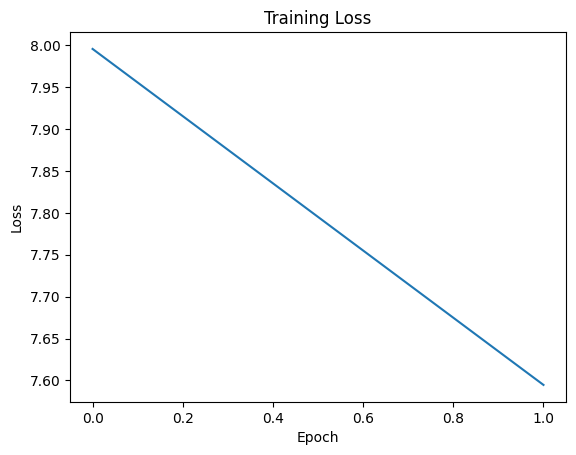

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


In [19]:
model.save("my_model.h5")


In [22]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 857, 100)       │       439,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 857, 150)       │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 857, 150)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4399)           │       444,299 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,405,599 (12.99 MB)

 Trainable params: 1,135,199 (4.33 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,270,400 (8.66 MB)

In [31]:
# Do not rebuild the model here — weights from training would be lost.
# The trained `model` is already in memory from the previous cells.
pass


In [32]:
import numpy as np

def generate_text(model, tokenizer, seed_text, next_words=40, temperature=0.8):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    if not token_list:
        return seed_text
    n_seed = len(token_list)
    reverse_word_map = {v: k for k, v in tokenizer.word_index.items()}
    for _ in range(next_words):
        padded = np.pad_sequences([token_list], maxlen=max_seq_len - 1, padding="pre")
        preds = model.predict(padded, verbose=0)[0]
        if temperature and temperature > 0:
            preds = np.asarray(preds, dtype="float64")
            preds = np.log(preds + 1e-10) / temperature
            exp_preds = np.exp(preds)
            preds = exp_preds / np.sum(exp_preds)
            next_idx = np.random.choice(len(preds), p=preds)
        else:
            next_idx = int(np.argmax(preds))
        token_list.append(next_idx)
    out_tokens = token_list[n_seed:]
    return seed_text + " " + " ".join(reverse_word_map.get(i, "") for i in out_tokens)

seed = " ".join(processed_texts[0][:5])
generated_text = generate_text(model, tokenizer, seed, next_words=40, temperature=0.8)
print(generated_text)


жоқ дес деп ақ бол білінгендікпен бар жоқ бұл сол секілді ол малғ баласының мал аристод деп бойын іс қашық ағайынжұртын тамақта ұрыбөріг егер ұрлық мырзалық жіберс кісінің аяма көкірект дауғ жоқ құдайғ баланың қойс қазақтың бірақ бір сүйтс боқтасқа
